# 1. Đếm số lượng ảnh train/test

In [1]:
import os
from pathlib import Path

DATASET_PATH = Path("/Users/mac/MeterReadAI/data/DataBeforeHandle/Word-Wheel_Water_Meter_Dataset/recognition/recognition_5-digit/test/5-digit_test_img")

dataset_imgs = list(DATASET_PATH.glob("*.*"))
print("Bộ dữ liệu test có: ", len(dataset_imgs))

Bộ dữ liệu test có:  2000


In [2]:
DATASET_PATH_2 = Path("/Users/mac/MeterReadAI/data/DataBeforeHandle/Word-Wheel_Water_Meter_Dataset/recognition/recognition_5-digit/train/5-digit_train_img")

dataset_imgs = list(DATASET_PATH_2.glob("*.*"))
print("Bộ dữ liệu train có: ", len(dataset_imgs))

Bộ dữ liệu train có:  11867


# 2. Kiểm tra tính trùng lặp ảnh

In [3]:
import hashlib
from collections import defaultdict

def check_duplicates(data_path):
    hash_dict = defaultdict(list)
    for img_path in data_path.glob("*.*"):
        with open(img_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
            hash_dict[file_hash].append(img_path.name)

    duplicates = {h: files for h, files in hash_dict.items() if len(files) > 1}

    if duplicates:
        print("Phát hiện các file trùng lặp chính xác:")
        for h, files in duplicates.items():
            print(f"- Nhóm trùng ({h}): {files}")
    else:
        print("Không tìm thấy file nào trùng lặp chính xác.")


In [4]:
check_duplicates(DATASET_PATH)

Không tìm thấy file nào trùng lặp chính xác.


In [5]:
check_duplicates(DATASET_PATH_2)

Phát hiện các file trùng lặp chính xác:
- Nhóm trùng (96f7a42de0d8e0685282043c8aeb89d5): ['train8744.jpg', 'train8747.jpg']
- Nhóm trùng (99533d1697274240cedbac1ec422db8e): ['train3956.jpg', 'train3957.jpg']
- Nhóm trùng (302aad8861424d9a0031a03b3a2ae46d): ['train8369.jpg', 'train8366.jpg']
- Nhóm trùng (22e43b653c268af5a84f124700a5355a): ['train7660.jpg', 'train7665.jpg']
- Nhóm trùng (767a34866ae56652fc8cc2a27d09d031): ['train4141.jpg', 'train4148.jpg']
- Nhóm trùng (a71d57cdd0736687a7e9e481eeb3dff2): ['train3997.jpg', 'train4002.jpg']
- Nhóm trùng (01a51f618f9a057f961f6f601b1a8955): ['train7663.jpg', 'train7664.jpg']
- Nhóm trùng (d3307df4173e54a9248ca024e8cd7c29): ['train4144.jpg', 'train4146.jpg']
- Nhóm trùng (f0861551b7f2cf2e83ba291b4830543b): ['train7831.jpg', 'train7833.jpg']
- Nhóm trùng (a30765d69e0d1dadacb2eff84e226a63): ['train9363.jpg', 'train9361.jpg']
- Nhóm trùng (444f72add198ab2bc4df9b12068c0a5a): ['train4900.jpg', 'train4908.jpg']
- Nhóm trùng (c77731192648089fa6e489

# 3. Visualize ảnh

test519.jpg
/Users/mac/MeterReadAI/data/DataBeforeHandle/Word-Wheel_Water_Meter_Dataset/recognition/recognition_5-digit/test/5-digit_test_img/test519.jpg


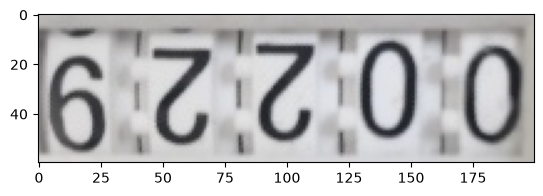

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
data_dict = os.listdir(DATASET_PATH)
print(data_dict[0])

path_img_0 = DATASET_PATH / data_dict[0]
print(path_img_0)

img_0 = Image.open(path_img_0)
plt.imshow(img_0)
plt.show()

# 4. Phân tích csv

In [15]:
import pandas as pd
csv_path = "/Users/mac/MeterReadAI/data/DataBeforeHandle/Word-Wheel_Water_Meter_Dataset/recognition/recognition_5-digit/test/5-digit_test_rec_label_CSV.csv"

df = pd.read_csv(csv_path, header=None)
print(df.head())

           0  1  2  3  4
0  test0.jpg  0  0  0  0
1  test1.jpg  0  0  0  0
2  test2.jpg  0  0  0  0
3  test3.jpg  0  0  0  0
4  test4.jpg  1  0  0  0
